In [1]:
import sys

print(sys.executable)

C:\Users\IDD23\anaconda3\envs\tp_project_env\python.exe


In [2]:
import pandas as pd
import numpy as np
import yaml

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("PyYAML: OK")

pandas: 3.0.3
numpy: 2.4.6
PyYAML: OK


In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

json_files = sorted(PROJECT_ROOT.rglob("*.json"))

print("Корень проекта:", PROJECT_ROOT)
print("Найдено JSON-файлов:", len(json_files))

for path in json_files:
    print(path.relative_to(PROJECT_ROOT))

Корень проекта: C:\Users\IDD23\OneDrive\Desktop\е\end-to-end-project
Найдено JSON-файлов: 256
.venv\etc\jupyter\jupyter_notebook_config.d\jupyterlab.json
.venv\etc\jupyter\jupyter_server_config.d\jupyter-lsp-jupyter-server.json
.venv\etc\jupyter\jupyter_server_config.d\jupyter_server_terminals.json
.venv\etc\jupyter\jupyter_server_config.d\jupyterlab.json
.venv\etc\jupyter\jupyter_server_config.d\notebook.json
.venv\etc\jupyter\jupyter_server_config.d\notebook_shim.json
.venv\etc\jupyter\nbconfig\notebook.d\widgetsnbextension.json
.venv\Lib\site-packages\debugpy\_vendored\pydevd\_pydevd_bundle\_debug_adapter\debugProtocol.json
.venv\Lib\site-packages\debugpy\_vendored\pydevd\_pydevd_bundle\_debug_adapter\debugProtocolCustom.json
.venv\Lib\site-packages\ipywidgets\state.schema.json
.venv\Lib\site-packages\ipywidgets\view.schema.json
.venv\Lib\site-packages\jsonschema\benchmarks\issue232\issue.json
.venv\Lib\site-packages\jsonschema_specifications\schemas\draft201909\metaschema.json
.ven

In [4]:
import json

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "events.json"

with RAW_PATH.open("r", encoding="utf-8") as f:
    raw = json.load(f)

print("Тип данных:", type(raw).__name__)

if isinstance(raw, dict):
    print("Ключи:", list(raw.keys())[:20])
    print("Количество ключей:", len(raw))
elif isinstance(raw, list):
    print("Количество записей:", len(raw))
    print("Первая запись:", raw[0] if raw else "список пуст")
else:
    print("Содержимое:", raw)

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
import json

RAW_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "variant_02"
    / "2026-09-15_03-46-15.json"
)

print("Файл:", RAW_PATH)
print("Размер:", RAW_PATH.stat().st_size, "байт")

with RAW_PATH.open("r", encoding="utf-8") as f:
    raw = json.load(f)

print("Тип данных:", type(raw).__name__)

if isinstance(raw, dict):
    print("Ключи:", list(raw.keys())[:20])
elif isinstance(raw, list):
    print("Количество записей:", len(raw))
    if raw:
        print("Первая запись:", raw[0])
else:
    print("Содержимое:", raw)

In [ ]:
hourly = raw["hourly"]

print("Ключи hourly:", list(hourly.keys()))
print("Количество временных точек:", len(hourly["time"]))

In [ ]:
df = pd.DataFrame(hourly)

df["time"] = pd.to_datetime(df["time"])

print("Размер таблицы:", df.shape)
print("Колонки:")
print(df.columns.tolist())

display(df.head())

In [ ]:
print(df.info())
display(df.describe(include="all").T)

In [ ]:
missing = (
    df.isna()
      .sum()
      .to_frame("missing_count")
)

missing["missing_percent"] = (
    missing["missing_count"] / len(df) * 100
).round(2)

display(missing)

In [ ]:
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NORMALIZED_PATH = OUTPUT_DIR / "weather_hourly_normalized.csv"

df.to_csv(NORMALIZED_PATH, index=False)

print("Сохранено:", NORMALIZED_PATH)

In [ ]:
print(df.info())

display(df.head())
display(df.tail())

In [ ]:
missing = df.isna().sum()

print("Пропуски по колонкам:")
display(missing)

print("Дубликаты строк:", df.duplicated().sum())
print("Дубликаты времени:", df["time"].duplicated().sum())

In [ ]:
display(df.describe().T)

In [ ]:
print("Начало периода:", df["time"].min())
print("Конец периода:", df["time"].max())
print("Количество строк:", len(df))
print("Количество уникальных временных точек:", df["time"].nunique())

In [ ]:
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NORMALIZED_PATH = OUTPUT_DIR / "weather_hourly_normalized.csv"

df.to_csv(
    NORMALIZED_PATH,
    index=False,
    encoding="utf-8"
)

print("Файл сохранён:")
print(NORMALIZED_PATH)

In [ ]:
daily = (
    df.set_index("time")
      .resample("D")
      .agg(
          temperature_mean=("temperature_2m", "mean"),
          temperature_min=("temperature_2m", "min"),
          temperature_max=("temperature_2m", "max"),
          humidity_mean=("relative_humidity_2m", "mean"),
          precipitation_total=("precipitation", "sum"),
          wind_speed_mean=("wind_speed_10m", "mean"),
          wind_speed_max=("wind_speed_10m", "max")
      )
      .reset_index()
)

daily = daily.round(2)

display(daily)

In [ ]:
warmest_day = daily.loc[
    daily["temperature_mean"].idxmax()
]

rainiest_day = daily.loc[
    daily["precipitation_total"].idxmax()
]

windiest_day = daily.loc[
    daily["wind_speed_max"].idxmax()
]

print("Самый тёплый день:")
display(warmest_day.to_frame().T)

print("Самый дождливый день:")
display(rainiest_day.to_frame().T)

print("День с максимальным ветром:")
display(windiest_day.to_frame().T)

In [ ]:
DAILY_PATH = OUTPUT_DIR / "weather_daily_summary.csv"

daily.to_csv(
    DAILY_PATH,
    index=False,
    encoding="utf-8"
)

print("Дневная таблица сохранена:")
print(DAILY_PATH)

In [ ]:
intervals = df["time"].sort_values().diff().dropna()

print("Интервалы между наблюдениями:")
display(intervals.value_counts())

In [ ]:
import matplotlib.pyplot as plt

FIGURES_DIR = PROJECT_ROOT / "data" / "processed" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 5))

df.plot.line(
    x="time",
    y="temperature_2m",
    ax=ax,
    color="tomato",
    linewidth=1.5,
    legend=False
)

ax.set_title("Почасовая температура")
ax.set_xlabel("Время")
ax.set_ylabel("Температура, °C")
ax.grid(True, alpha=0.3)

fig.tight_layout()

temperature_plot = FIGURES_DIR / "temperature_hourly.png"
fig.savefig(temperature_plot, dpi=150)
plt.show()

print("Сохранено:", temperature_plot)

In [ ]:
import matplotlib

print(matplotlib.__version__)

In [ ]:
import matplotlib.pyplot as plt

FIGURES_DIR = PROJECT_ROOT / "data" / "processed" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 5))

df.plot.line(
    x="time",
    y="temperature_2m",
    ax=ax,
    color="tomato",
    linewidth=1.5,
    legend=False
)

ax.set_title("Почасовая температура")
ax.set_xlabel("Время")
ax.set_ylabel("Температура, °C")
ax.grid(True, alpha=0.3)

fig.tight_layout()

temperature_plot = FIGURES_DIR / "temperature_hourly.png"
fig.savefig(temperature_plot, dpi=150)
plt.show()

print("Сохранено:", temperature_plot)

In [ ]:
import matplotlib.pyplot as plt

FIGURES_DIR = PROJECT_ROOT / "data" / "processed" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 5))

df.plot.line(
    x="time",
    y="temperature_2m",
    ax=ax,
    color="tomato",
    linewidth=1.5,
    legend=False
)

ax.set_title("Почасовая температура")
ax.set_xlabel("Время")
ax.set_ylabel("Температура, °C")
ax.grid(True, alpha=0.3)

fig.tight_layout()

temperature_plot = FIGURES_DIR / "temperature_hourly.png"
fig.savefig(temperature_plot, dpi=150)
plt.show()

print("Сохранено:", temperature_plot)

In [5]:
from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\IDD23\OneDrive\Desktop\е\end-to-end-project"
)

print(PROJECT_ROOT)

C:\Users\IDD23\OneDrive\Desktop\е\end-to-end-project


In [6]:
import json
import pandas as pd

RAW_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "variant_02"
    / "2026-09-15_03-46-15.json"
)

with RAW_PATH.open("r", encoding="utf-8") as f:
    raw = json.load(f)

hourly = raw["hourly"]
df = pd.DataFrame(hourly)
df["time"] = pd.to_datetime(df["time"])

print(df.shape)

(168, 5)


In [7]:
daily = (
    df.set_index("time")
      .resample("D")
      .agg(
          temperature_mean=("temperature_2m", "mean"),
          temperature_min=("temperature_2m", "min"),
          temperature_max=("temperature_2m", "max"),
          humidity_mean=("relative_humidity_2m", "mean"),
          precipitation_total=("precipitation", "sum"),
          wind_speed_mean=("wind_speed_10m", "mean"),
          wind_speed_max=("wind_speed_10m", "max")
      )
      .reset_index()
      .round(2)
)

C:\Users\IDD23\AppData\Local\Temp\ipykernel_7556\1630897576.py:14: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


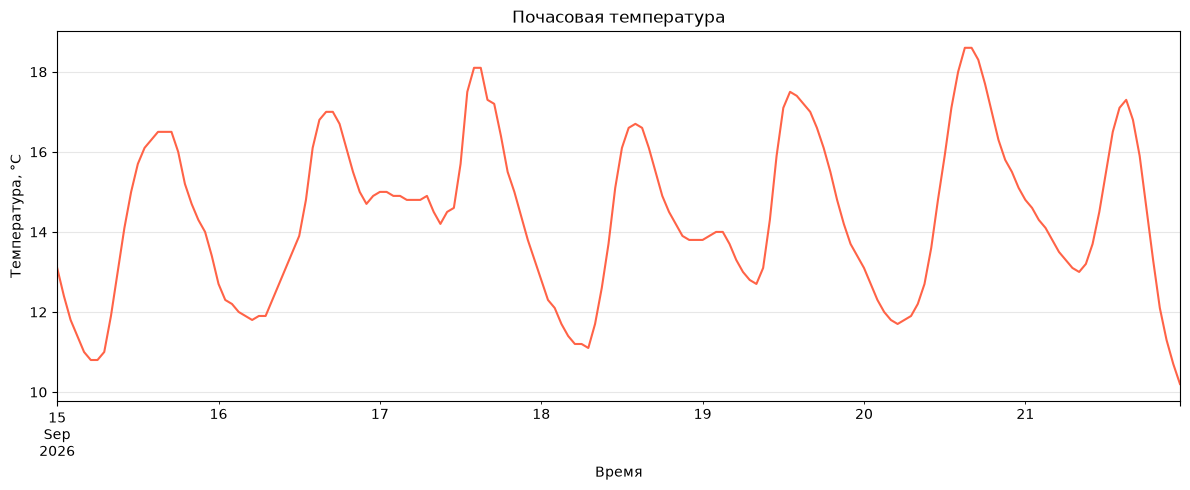

Сохранено: C:\Users\IDD23\OneDrive\Desktop\е\end-to-end-project\data\processed\figures\temperature_hourly.png


In [8]:
import matplotlib.pyplot as plt

FIGURES_DIR = PROJECT_ROOT / "data" / "processed" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 5))

df.plot.line(
    x="time",
    y="temperature_2m",
    ax=ax,
    color="tomato",
    linewidth=1.5,
    legend=False
)

ax.set_title("Почасовая температура")
ax.set_xlabel("Время")
ax.set_ylabel("Температура, °C")
ax.grid(True, alpha=0.3)

fig.tight_layout()

temperature_plot = FIGURES_DIR / "temperature_hourly.png"
fig.savefig(temperature_plot, dpi=150)
plt.show()

print("Сохранено:", temperature_plot)

C:\Users\IDD23\AppData\Local\Temp\ipykernel_7556\417592949.py:43: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


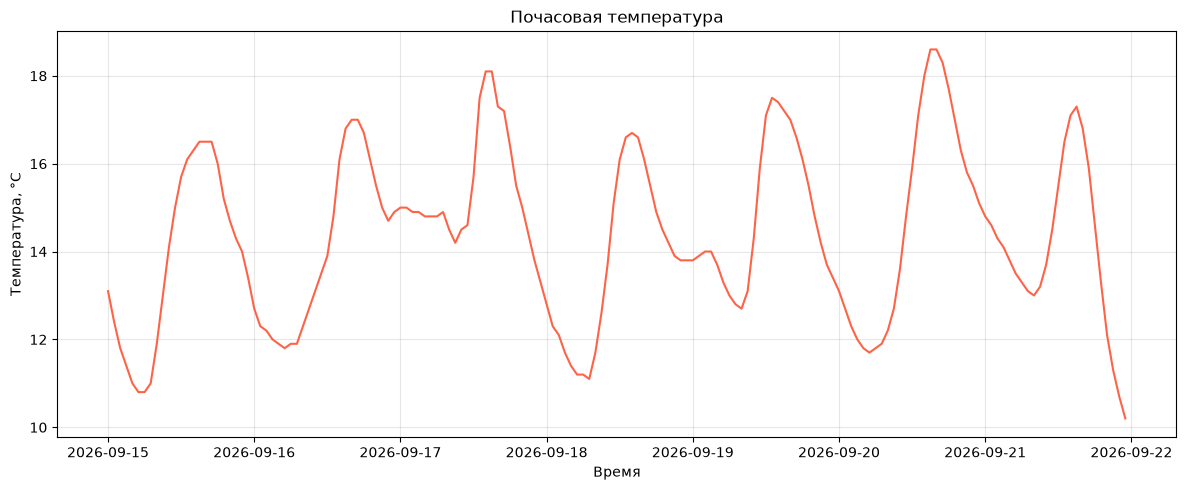

Готово.
Строк в hourly: 168
Строк в daily: 7
CSV: C:\Users\IDD23\OneDrive\Desktop\е\end-to-end-project\data\processed
График: C:\Users\IDD23\OneDrive\Desktop\е\end-to-end-project\data\processed\figures\temperature_hourly.png


In [9]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(
    r"C:\Users\IDD23\OneDrive\Desktop\е\end-to-end-project"
)

RAW_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "variant_02"
    / "2026-09-15_03-46-15.json"
)

with RAW_PATH.open("r", encoding="utf-8") as f:
    raw = json.load(f)

df = pd.DataFrame(raw["hourly"])
df["time"] = pd.to_datetime(df["time"])

OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

daily = (
    df.set_index("time")
      .resample("D")
      .agg(
          temperature_mean=("temperature_2m", "mean"),
          temperature_min=("temperature_2m", "min"),
          temperature_max=("temperature_2m", "max"),
          humidity_mean=("relative_humidity_2m", "mean"),
          precipitation_total=("precipitation", "sum"),
          wind_speed_mean=("wind_speed_10m", "mean"),
          wind_speed_max=("wind_speed_10m", "max")
      )
      .reset_index()
      .round(2)
)

df.to_csv(
    OUTPUT_DIR / "weather_hourly_normalized.csv",
    index=False,
    encoding="utf-8"
)

daily.to_csv(
    OUTPUT_DIR / "weather_daily_summary.csv",
    index=False,
    encoding="utf-8"
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    df["time"],
    df["temperature_2m"],
    color="tomato",
    linewidth=1.5
)

ax.set_title("Почасовая температура")
ax.set_xlabel("Время")
ax.set_ylabel("Температура, °C")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "temperature_hourly.png",
    dpi=150
)
plt.show()
plt.close(fig)

print("Готово.")
print("Строк в hourly:", len(df))
print("Строк в daily:", len(daily))
print("CSV:", OUTPUT_DIR)
print("График:", FIGURES_DIR / "temperature_hourly.png")